In [1]:
import pandas as pd
import numpy as np

In [2]:
data = pd.read_csv('map_data.csv')

In [4]:
X = data[['x', 'y']].values

Y = data['label'].values

In [5]:
import torch
import torch.nn as nn
import torch.functional as F
import torch.optim as optim

In [8]:
class DeepNet3(nn.Module):
    def __init__(self, inp_size = 2, h1_size = 2, h2_size = 2, h3_size = 2, output_size = 2):
        super(DeepNet3, self).__init__()
        self.h1 = nn.Linear(inp_size, h1_size)
        self.bn1 = nn.BatchNorm1d(h1_size)
        self.h2 = nn.Linear(h1_size, h2_size)
        self.bn2 = nn.BatchNorm1d(h2_size)
        self.h3 = nn.Linear(h2_size, h3_size)
        self.bn3 = nn.BatchNorm1d(h3_size)
        self.output = nn.Linear(h3_size, output_size)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.h1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.h2(x)
        x = self.bn2(x)
        x = self.relu(x)
        x = self.h3(x)
        x = self.bn3(x)
        x = self.relu(x)
        x = self.output(x)
        return x
    
deepmodel = DeepNet3(inp_size = 2, h1_size = 6, h2_size = 6, h3_size = 6, output_size = 2)
loss_fn = nn.CrossEntropyLoss()
optimizer = optim.Adam(deepmodel.parameters(), lr = 0.1)

for epoch in range(200):
    # forward pass
    inputs = torch.tensor(X, dtype = torch.float32)
    labels = torch.tensor(Y, dtype = torch.long)
    outputs = deepmodel(inputs)

    # loss
    loss = loss_fn(outputs, labels)

    # back prop
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if epoch % 10 == 0:
        print(f"Epoch {epoch}:- Loss: {loss:.4f}")


Epoch 0:- Loss: 0.8753
Epoch 10:- Loss: 0.3437
Epoch 20:- Loss: 0.3170
Epoch 30:- Loss: 0.2977
Epoch 40:- Loss: 0.2871
Epoch 50:- Loss: 0.2775
Epoch 60:- Loss: 0.2736
Epoch 70:- Loss: 0.2725
Epoch 80:- Loss: 0.2701
Epoch 90:- Loss: 0.2683
Epoch 100:- Loss: 0.2672
Epoch 110:- Loss: 0.2665
Epoch 120:- Loss: 0.2633
Epoch 130:- Loss: 0.2612
Epoch 140:- Loss: 0.2589
Epoch 150:- Loss: 0.2584
Epoch 160:- Loss: 0.2562
Epoch 170:- Loss: 0.2528
Epoch 180:- Loss: 0.2444
Epoch 190:- Loss: 0.2374


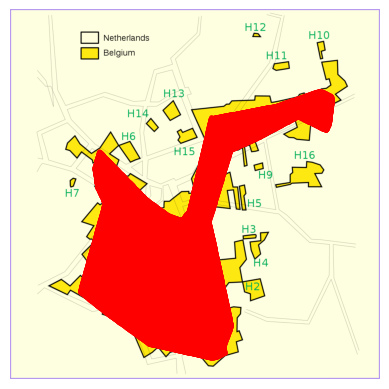

In [10]:
# plot
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

img = mpimg.imread('Baarle-Nassau_Baarle-Hertog.png')
plt.imshow(img)
plt.axis('off')

inputs = torch.tensor(X, dtype = torch.float32)

with torch.no_grad():
    outputs = deepmodel(inputs)
    preds = torch.argmax(outputs, dim = 1).numpy()

plt.scatter(X[preds == 1, 0], X[preds == 1, 1], c = 'red', s = 4, label = 'Netherlands', alpha = 0.5)
plt.scatter(X[preds == 0, 0], X[preds == 0, 1], c = 'none', s = 4, label = 'Belgium', alpha = 0.5)  